# IMPORT

In [119]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [120]:
raw_data = pd.read_csv('employee_attrition_2026_master.csv')
dict01 = pd.read_csv('data_dictionary.csv')

# Checking Missing / Duplicate / raw_data Type

In [121]:
raw_data.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


In [122]:
dict01

,column,type,description
0,employee_id,string,Unique employee id
1,age,int,Age in years
2,generation,string,Gen Z / Millennial / Gen X / Boomer (derived f...
3,gender,string,Male / Female / Other
4,department,string,"Department (Engineering, Product, Sales, Opera..."
5,job_level,string,Junior / Mid / Senior / Lead / Manager / Director
6,is_manager,int,1 if a people-manager role (Lead/Manager/Direc...
7,tenure_years,float,Years at the company
8,salary_usd,int,Annual salary (USD)
9,salary_vs_market_pct,float,"Salary vs market benchmark (%), negative = und..."


In [123]:
print(raw_data.dtypes)

employee_id                    object
age                             int64
generation                     object
gender                         object
department                     object
job_level                      object
is_manager                      int64
tenure_years                  float64
salary_usd                      int64
salary_vs_market_pct          float64
work_arrangement               object
rto_mandate                     int64
days_in_office_required         int64
commute_minutes                 int64
prefers_remote                  int64
flexibility_importance          int64
ai_tools_adoption              object
weekly_hours                    int64
after_hours_work                int64
burnout_score                 float64
manager_relationship_score      int64
manager_1on1_per_month          int64
engagement_score                int64
promotions_last_2y              int64
career_growth_score             int64
recent_layoff_round             int64
team_size   

In [124]:
print(f"duplicated = {raw_data.duplicated().sum()}")
print(f"size = {raw_data.size}")
print(f"shape = {raw_data.shape}\n")
print(f"Missing raw_data\n{raw_data.isnull().sum()}")

duplicated = 0
size = 1305000
shape = (45000, 29)

Missing raw_data
employee_id                   0
age                           0
generation                    0
gender                        0
department                    0
job_level                     0
is_manager                    0
tenure_years                  0
salary_usd                    0
salary_vs_market_pct          0
work_arrangement              0
rto_mandate                   0
days_in_office_required       0
commute_minutes               0
prefers_remote                0
flexibility_importance        0
ai_tools_adoption             0
weekly_hours                  0
after_hours_work              0
burnout_score                 0
manager_relationship_score    0
manager_1on1_per_month        0
engagement_score              0
promotions_last_2y            0
career_growth_score           0
recent_layoff_round           0
team_size                     0
attrition_reason              0
attrition                     0
dtyp

ตัด เริ่มงานตั้งแต่อายุต่ำกว่า 16 เพราะว่ามีคนที่เริ่มงานตั้งแต่อายุ age=20, แต่อายุงาน tenure_years=9.8

In [125]:
bad_mask = raw_data["tenure_years"] > (raw_data["age"] - 16)
n_bad = bad_mask.sum()

clean_data = raw_data[~bad_mask].reset_index(drop=True)


In [126]:
clean_data.head()

,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


# EDA & Visualization: ปัจจัยที่สัมพันธ์กับ Attrition

เป้าหมาย: สำรวจข้อมูลเชิงลึก (Exploratory Data Analysis) เพื่อดูว่าปัจจัยใดบ้างที่สัมพันธ์กับการลาออกของพนักงาน (`attrition`) ก่อนนำผลลัพธ์ไปใช้ออกแบบ feature และเลือกโมเดลสำหรับทำนายการลาออกในขั้นตอนถัดไป

ใช้ `clean_data` ที่ผ่านการทำความสะอาดแล้ว (ก่อน encoding) เพื่อให้กราฟยังอ่านค่าหมวดหมู่ (categorical) ได้ตรงตัว เช่น ชื่อ department, work_arrangement เป็นต้น

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.unicode_minus'] = False

# หมายเหตุ: ข้อความในกราฟ (title/label) ใช้ภาษาอังกฤษ เพราะฟอนต์ default ของ matplotlib
# ไม่รองรับตัวอักษรไทย (จะเห็นเป็นกล่องสี่เหลี่ยม) — คำอธิบาย insight เขียนเป็นภาษาไทยในเซลล์ markdown แทน

## 1) ภาพรวม: สัดส่วนการลาออก (Target Distribution)

Stayed (0): 35,508 คน (81.7%)
Left   (1): 7,931 คน (18.3%)


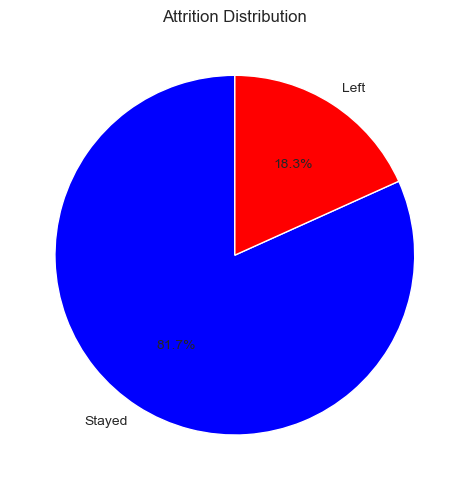

In [128]:
attr_counts = clean_data['attrition'].value_counts().sort_index()
attr_pct = clean_data['attrition'].value_counts(normalize=True).sort_index() * 100

print(f"Stayed (0): {attr_counts[0]:,} คน ({attr_pct[0]:.1f}%)")
print(f"Left   (1): {attr_counts[1]:,} คน ({attr_pct[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(attr_counts.values, labels=['Stayed','Left'], autopct='%1.1f%%',
       colors=['blue','red'], startangle=90)
ax.set_title('Attrition Distribution')
plt.tight_layout()
plt.show()

**Insight:** พนักงานลาออกประมาณ **18.3%** ของทั้งหมด ถือว่าเป็น imbalanced target พอสมควร (ไม่ balance 50/50) ซึ่งมีผลต่อการสร้างโมเดลทำนายในขั้นตอนถัดไป — ต้องพิจารณาเทคนิคจัดการ class imbalance เช่น class_weight, SMOTE หรือเลือก metric ที่เหมาะสม (Recall, F1, ROC-AUC) แทนการดู Accuracy อย่างเดียว เพราะถ้าโมเดลทายว่า "ไม่ลาออก" ทุกคน ก็จะได้ accuracy ~82% ทั้งที่ไม่มีประโยชน์เลย

## 2) Correlation Overview: ปัจจัยเชิงตัวเลขที่สัมพันธ์กับ Attrition

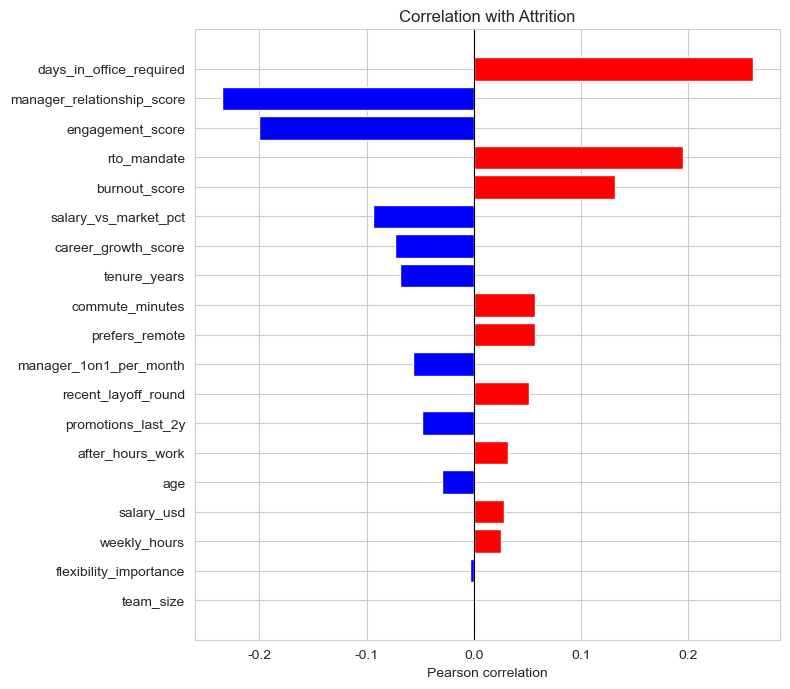

Top 8 ปัจจัยที่สัมพันธ์กับ Attrition มากที่สุด (|correlation| สูงสุด):
days_in_office_required       0.260487
manager_relationship_score   -0.234950
engagement_score             -0.200512
rto_mandate                   0.195317
burnout_score                 0.131412
salary_vs_market_pct         -0.093825
career_growth_score          -0.073622
tenure_years                 -0.069224
Name: attrition, dtype: float64


In [129]:
num_cols = ['age','tenure_years','salary_usd','salary_vs_market_pct','days_in_office_required',
            'commute_minutes','flexibility_importance','weekly_hours','after_hours_work',
            'burnout_score','manager_relationship_score','manager_1on1_per_month','engagement_score',
            'promotions_last_2y','career_growth_score','recent_layoff_round','team_size','rto_mandate',
            'prefers_remote','attrition']

corr_with_target = clean_data[num_cols].corr()['attrition'].drop('attrition').sort_values(key=abs)

fig, ax = plt.subplots(figsize=(8,7))
colors = ['red' if v > 0 else 'blue' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation with Attrition')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print("Top 8 ปัจจัยที่สัมพันธ์กับ Attrition มากที่สุด (|correlation| สูงสุด):")
print(corr_with_target.sort_values(key=abs, ascending=False).head(8))

**Insight:** ปัจจัยที่สัมพันธ์กับการลาออกแรงที่สุด (เรียงตามค่าสัมบูรณ์ของ correlation) คือ
1. **days_in_office_required** (+0.26) — ยิ่งบังคับเข้าออฟฟิศหลายวัน ยิ่งลาออกเยอะ
2. **manager_relationship_score** (-0.23) — ความสัมพันธ์กับหัวหน้าดี ช่วยลดการลาออกได้ชัดเจน
3. **engagement_score** (-0.20) — ความผูกพันกับองค์กร/งานต่ำ สัมพันธ์กับการลาออกสูง
4. **rto_mandate** (+0.20) — บริษัทที่มีนโยบายเรียกกลับเข้าออฟฟิศ (RTO) มีอัตราลาออกสูงกว่า
5. **burnout_score** (+0.13) — ภาวะหมดไฟสัมพันธ์ทางบวกกับการลาออก

จะเห็นว่ากลุ่มปัจจัยเรื่อง **รูปแบบการทำงาน/ความยืดหยุ่น (Work Arrangement)** และ **คุณภาพความสัมพันธ์กับหัวหน้า/engagement** มีอิทธิพลมากกว่าปัจจัยประชากรศาสตร์อย่าง age หรือ salary_usd ซึ่งแทบไม่มีความสัมพันธ์เลย (|corr| < 0.03)

## 3) Work Arrangement & RTO Mandate

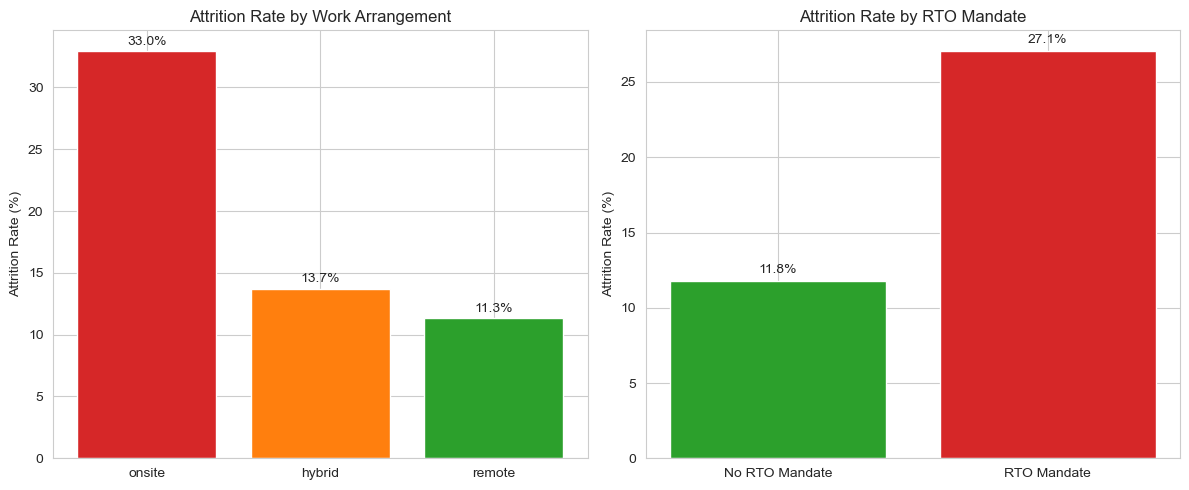

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

wa_rate = clean_data.groupby('work_arrangement')['attrition'].mean().sort_values(ascending=False) * 100
axes[0].bar(wa_rate.index, wa_rate.values, color=['#d62728','#ff7f0e','#2ca02c'])
axes[0].set_title('Attrition Rate by Work Arrangement')
axes[0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(wa_rate.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

rto_rate = clean_data.groupby('rto_mandate')['attrition'].mean() * 100
axes[1].bar(['No RTO Mandate','RTO Mandate'], rto_rate.values, color=['#2ca02c','#d62728'])
axes[1].set_title('Attrition Rate by RTO Mandate')
axes[1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(rto_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**Insight:** พนักงานที่ทำงาน **onsite** ลาออกสูงถึง **~33%** เทียบกับ hybrid (~13.7%) และ remote (~11.3%) — รูปแบบ onsite มีอัตราลาออกสูงกว่า remote เกือบ 3 เท่า และบริษัทที่ประกาศ **RTO mandate** ก็มีอัตราลาออก (~27%) สูงกว่าบริษัทที่ไม่มีมาตรการนี้ (~12%) เกือบ 2.3 เท่า สะท้อนว่าในบริบทปี 2026 ความยืดหยุ่นด้านสถานที่ทำงานเป็นปัจจัยผลักดัน (push factor) ที่สำคัญมากต่อการตัดสินใจลาออก

### Remote-preference Mismatch (อยากทำงานรีโมท แต่ถูกบังคับเข้าออฟฟิศ)

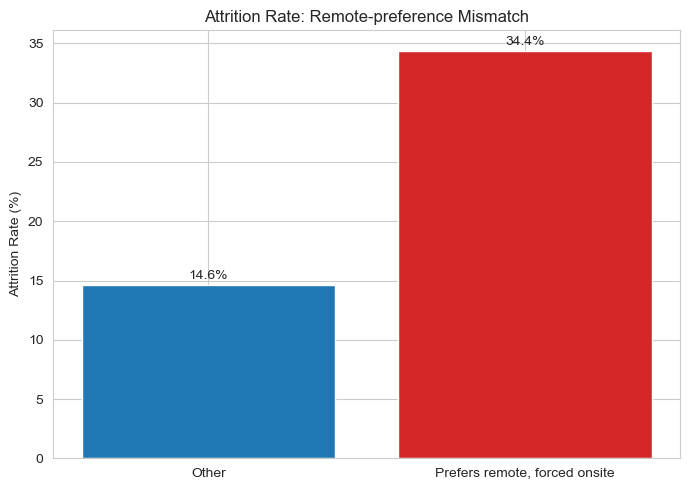

In [131]:
clean_data['remote_mismatch'] = np.where(
    (clean_data['prefers_remote'] == 1) & (clean_data['work_arrangement'] == 'onsite'),
    'Prefers remote, forced onsite', 'Other'
)

mismatch_rate = clean_data.groupby('remote_mismatch')['attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(mismatch_rate.index, mismatch_rate.values, color=['#1f77b4','#d62728'])
ax.set_title('Attrition Rate: Remote-preference Mismatch')
ax.set_ylabel('Attrition Rate (%)')
for i, v in enumerate(mismatch_rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Insight:** กลุ่มพนักงานที่ **อยากทำงานรีโมทแต่ถูกบังคับให้เข้าออฟฟิศ (onsite)** มีอัตราลาออกสูงถึง **~34.4%** เทียบกับกลุ่มอื่น ๆ ที่ ~14.6% (สูงกว่ากว่า 2 เท่า) นี่คือสัญญาณที่ชัดเจนว่า "ความไม่ตรงกัน" ระหว่างความต้องการของพนักงานกับนโยบายบริษัท (person-organization mismatch) เป็นตัวขับเคลื่อนการลาออกที่แรงกว่าการดู work_arrangement หรือ prefers_remote แยกกัน — ควรพิจารณาสร้างเป็น feature ใหม่ (interaction feature) สำหรับโมเดลทำนาย

## 4) Burnout Score

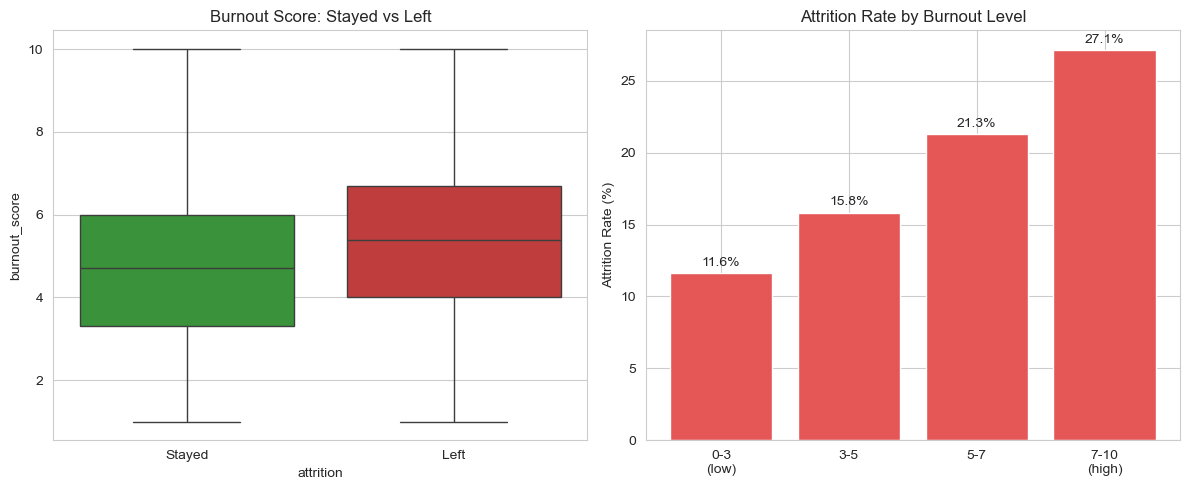

In [132]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=clean_data, x='attrition', y='burnout_score', hue='attrition',
            palette=['#2ca02c','#d62728'], legend=False, ax=ax[0])
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['Stayed','Left'])
ax[0].set_title('Burnout Score: Stayed vs Left')

clean_data['burnout_bin'] = pd.cut(clean_data['burnout_score'], bins=[0,3,5,7,10],
                                    labels=['0-3\n(low)','3-5','5-7','7-10\n(high)'])
burnout_rate = clean_data.groupby('burnout_bin', observed=True)['attrition'].mean() * 100
ax[1].bar(burnout_rate.index.astype(str), burnout_rate.values, color='#e45756')
ax[1].set_title('Attrition Rate by Burnout Level')
ax[1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(burnout_rate.values):
    ax[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**Insight:** ค่ามัธยฐาน burnout_score ของกลุ่มที่ลาออกสูงกว่ากลุ่มที่อยู่ต่ออย่างชัดเจน และอัตราการลาออกเพิ่มขึ้น**เป็นขั้นบันได** ตาม burnout: จาก ~11.6% ในกลุ่ม burnout ต่ำ (0-3) ไปจนถึง ~27.1% ในกลุ่ม burnout สูง (7-10) — ความสัมพันธ์เป็นแบบ monotonic (ยิ่งหมดไฟ ยิ่งลาออกเยอะ) ทำให้ burnout_score เป็นตัวแปรเชิงพฤติกรรม (behavioral signal) ที่มีประโยชน์มากสำหรับโมเดลทำนาย และเป็นสัญญาณเตือนล่วงหน้าที่ HR ใช้ติดตามได้

## 5) Engagement Score (ตัวแทน Job Satisfaction)

หมายเหตุ: ชุดข้อมูลนี้ไม่มีคอลัมน์ "job satisfaction" ตรง ๆ แต่ `engagement_score` (คะแนนความผูกพันต่อองค์กรจากแบบสำรวจ) เป็นตัวแทนที่ใกล้เคียงที่สุดในการวัดความพึงพอใจ/ความผูกพันในงาน

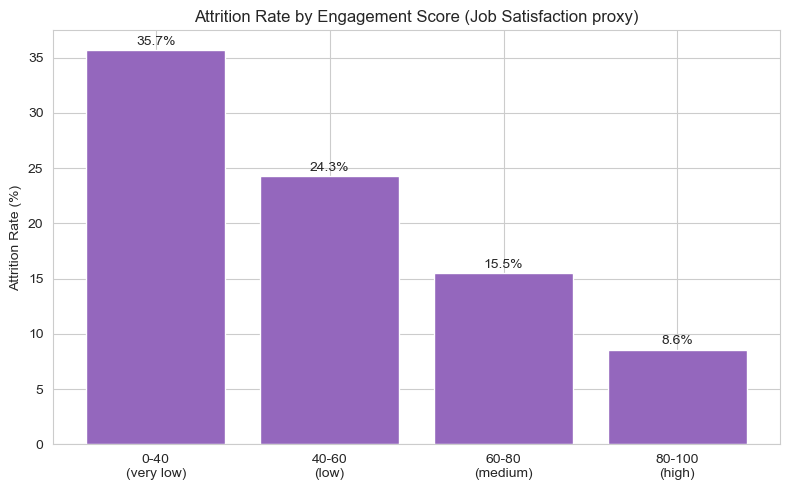

In [133]:
clean_data['engagement_bin'] = pd.cut(clean_data['engagement_score'], bins=[0,40,60,80,100],
                                       labels=['0-40\n(very low)','40-60\n(low)','60-80\n(medium)','80-100\n(high)'])
eng_rate = clean_data.groupby('engagement_bin', observed=True)['attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(eng_rate.index.astype(str), eng_rate.values, color='#9467bd')
ax.set_title('Attrition Rate by Engagement Score (Job Satisfaction proxy)')
ax.set_ylabel('Attrition Rate (%)')
for i, v in enumerate(eng_rate.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Insight:** กลุ่มที่มี engagement ต่ำมาก (0-40) ลาออกสูงถึง **~35.7%** ในขณะที่กลุ่ม engagement สูง (80-100) ลาออกเพียง **~8.6%** ต่างกันกว่า 4 เท่า และเป็นหนึ่งในปัจจัยที่มีความสัมพันธ์แรงที่สุดในชุดข้อมูล (corr = -0.20) ยืนยันหลักการพื้นฐานด้าน HR ว่า "ความพึงพอใจ/ความผูกพันในงานต่ำ" เป็นตัวทำนายการลาออกที่ทรงพลัง ควรใช้เป็น feature หลักในโมเดล

## 6) Manager Relationship Score

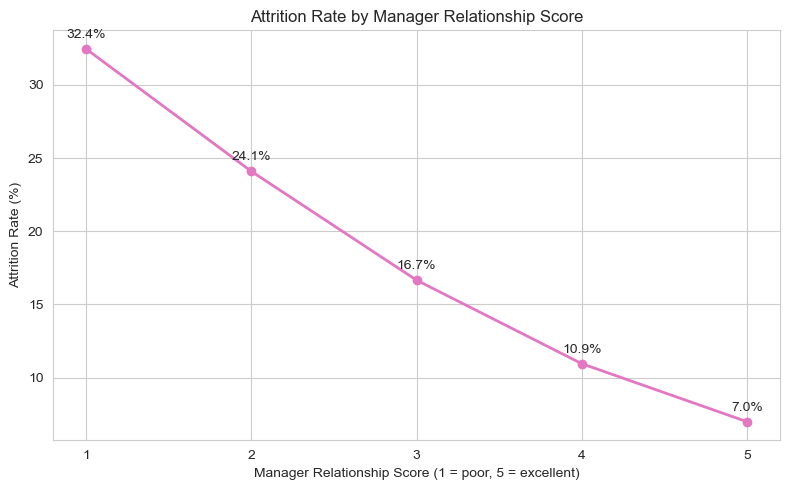

In [134]:
mgr_rate = clean_data.groupby('manager_relationship_score')['attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(mgr_rate.index, mgr_rate.values, marker='o', linewidth=2, color='#e377c2')
for x, y in zip(mgr_rate.index, mgr_rate.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0,8), ha='center')
ax.set_title('Attrition Rate by Manager Relationship Score')
ax.set_xlabel('Manager Relationship Score (1 = poor, 5 = excellent)')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()

**Insight:** ความสัมพันธ์เป็นเส้นตรงลดลงอย่างชัดเจน — จากคะแนน 1 (แย่ที่สุด) อัตราลาออก **~32.4%** ลดลงเรื่อย ๆ จนเหลือ **~7.0%** ที่คะแนน 5 (ดีที่สุด) ต่างกันเกือบ 5 เท่า ทำให้ manager_relationship_score เป็นหนึ่งในปัจจัยที่สัมพันธ์กับ attrition แรงที่สุด (corr = -0.23) บ่งชี้ว่าการลงทุนพัฒนาทักษะการบริหารคนของหัวหน้างาน (people management) อาจช่วยลดอัตราการลาออกได้อย่างมีนัยสำคัญ

## 7) Age & Years at Company (Tenure)

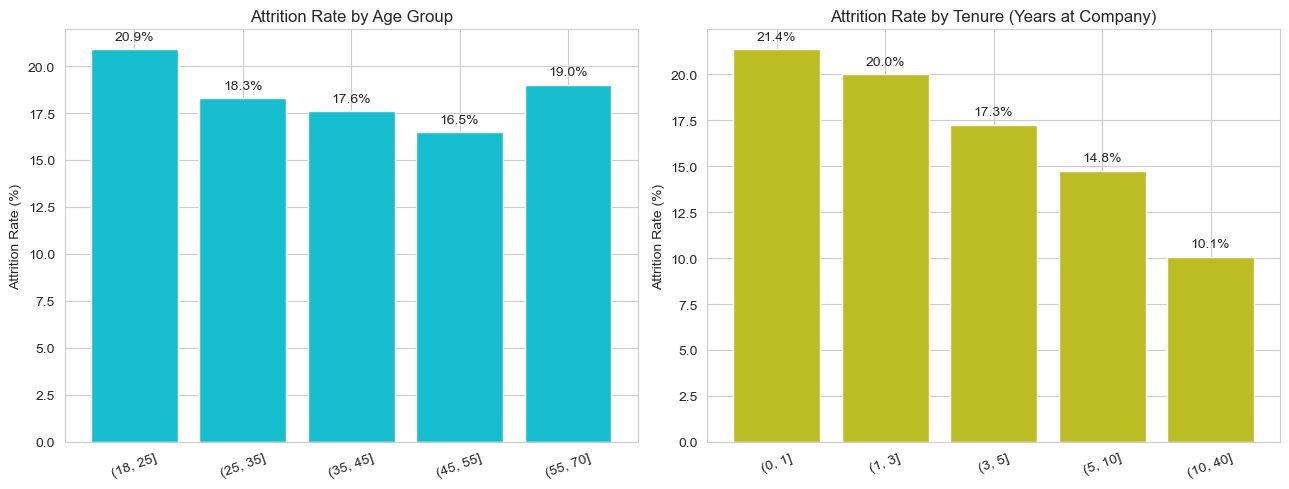

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

clean_data['age_bin'] = pd.cut(clean_data['age'], bins=[18,25,35,45,55,70])
age_rate = clean_data.groupby('age_bin', observed=True)['attrition'].mean() * 100
axes[0].bar(age_rate.index.astype(str), age_rate.values, color='#17becf')
axes[0].set_title('Attrition Rate by Age Group')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(age_rate.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

clean_data['tenure_bin'] = pd.cut(clean_data['tenure_years'], bins=[0,1,3,5,10,40])
tenure_rate = clean_data.groupby('tenure_bin', observed=True)['attrition'].mean() * 100
axes[1].bar(tenure_rate.index.astype(str), tenure_rate.values, color='#bcbd22')
axes[1].set_title('Attrition Rate by Tenure (Years at Company)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(tenure_rate.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

**Insight:**
- **Age:** ความสัมพันธ์กับ attrition ค่อนข้างอ่อน (corr ≈ -0.03) กลุ่มอายุน้อย (18-25 ปี) ลาออกสูงสุดเล็กน้อย (~20.9%) และมีแนวโน้มลดลงในช่วงอายุกลาง ก่อนขยับขึ้นอีกครั้งเล็กน้อยในกลุ่มอายุมาก — ไม่ใช่ปัจจัยหลักเมื่อเทียบกับปัจจัยอื่น
- **Tenure (อายุงาน):** มีความสัมพันธ์ชัดเจนกว่า — พนักงานที่เพิ่งเข้าใหม่ (0-1 ปี) ลาออกสูงสุด (~21.4%) และอัตราลาออกลดลงเรื่อย ๆ ตามอายุงานที่เพิ่มขึ้น จนเหลือเพียง ~10.1% ในกลุ่มที่อยู่มากกว่า 10 ปี สอดคล้องกับปรากฏการณ์ทั่วไปที่พนักงานใหม่มีความเสี่ยงลาออกสูงในช่วง onboarding และมีความผูกพันมากขึ้นเมื่อสะสมอายุงาน

## สรุปผล EDA (Key Takeaways) และแนวทางต่อสำหรับโมเดลทำนาย

**ปัจจัยที่สัมพันธ์กับ Attrition มากที่สุด** (เรียงตามความแรง):

| อันดับ | ปัจจัย | ทิศทาง | ผลกระทบ |
|---|---|---|---|
| 1 | days_in_office_required / work_arrangement | ยิ่งเข้าออฟฟิศเยอะ ยิ่งลาออกเยอะ | Onsite ~33% vs Remote ~11% |
| 2 | manager_relationship_score | ยิ่งความสัมพันธ์ดี ยิ่งลาออกน้อย | คะแนน 1 → 32% เทียบกับคะแนน 5 → 7% |
| 3 | engagement_score | ยิ่งผูกพันสูง ยิ่งลาออกน้อย | ต่ำสุด ~36% เทียบกับสูงสุด ~9% |
| 4 | rto_mandate | บริษัทมี RTO มีอัตราลาออกสูงกว่า | ~27% vs ~12% |
| 5 | burnout_score | ยิ่งหมดไฟ ยิ่งลาออกเยอะ (monotonic) | ~12% → ~27% |
| 6 | remote-preference mismatch (feature ใหม่) | อยากรีโมทแต่ถูกบังคับ onsite | ~34% vs ~15% |
| 7 | career_growth_score, tenure_years | ยิ่งมีโอกาสเติบโต/อยู่นาน ยิ่งลาออกน้อย | ผลปานกลาง |
| - | age, salary_usd, team_size, flexibility_importance | สัมพันธ์อ่อนมาก (|corr| < 0.03) | ไม่ใช่ปัจจัยหลัก |

**ข้อสังเกตสำคัญเชิงธุรกิจ:** ปัจจัยกลุ่ม "Modern work factors" (work_arrangement, rto_mandate, prefers_remote, ai_tools_adoption) และปัจจัยด้านความสัมพันธ์/engagement มีอิทธิพลต่อการลาออกมากกว่าปัจจัยประชากรศาสตร์แบบดั้งเดิม (age, gender) อย่างชัดเจน สะท้อนบริบทตลาดแรงงานปี 2026 ที่ให้ความสำคัญกับความยืดหยุ่นในการทำงานมากขึ้น

**แนวทางต่อสำหรับการสร้างโมเดลทำนาย (Next Steps):**
1. **Feature Engineering:** สร้าง interaction feature เพิ่มเติม เช่น `remote_mismatch` (ทำแล้วด้านบน), `burnout x weekly_hours`, หรือจัดกลุ่ม tenure/age เป็น bin
2. **จัดการ Class Imbalance:** attrition มีเพียง ~18% ควรใช้ `class_weight='balanced'`, oversampling (SMOTE) หรือปรับ threshold แทนการใช้ default
3. **โมเดลที่ควรทดลอง:** เริ่มจาก Logistic Regression (baseline + ตีความง่าย) แล้วต่อด้วย Random Forest / Gradient Boosting (XGBoost, LightGBM) เพื่อจับ non-linear relationship และ interaction ระหว่างตัวแปร
4. **Metric ที่ควรดู:** Recall/F1 ของ class "Left" และ ROC-AUC / PR-AUC แทน Accuracy อย่างเดียว เนื่องจากธุรกิจสนใจ "จับให้ได้ว่าใครมีความเสี่ยงจะลาออก" มากกว่าความแม่นยำโดยรวม
5. **Feature Importance:** หลังสร้างโมเดลแล้ว ควรตรวจสอบว่าผลลัพธ์สอดคล้องกับ insight จาก EDA นี้หรือไม่ (เช่น manager_relationship_score, engagement_score, work_arrangement ควรติดอันดับ top features)

# encoding 

job_level มีลำดับจริง (Junior<Mid<Senior<Lead<Manager<Director) OrdinalEncoder

ai_order มีลำดับจริง ("none<light<regular<power) OrdinalEncoder

gender, department, work_arrangement, ไม่มีลำดับ ใช้ OneHotEncoder


In [136]:
job_level_order = ["Junior", "Mid", "Senior", "Lead", "Manager", "Director"]
clean_data["job_level"] = pd.Categorical(clean_data["job_level"], categories=job_level_order, ordered=True).codes
clean_data["job_level"].value_counts().sort_index()

job_level
0    10418
1    13001
2     9508
3     4452
4     4361
5     1699
Name: count, dtype: int64

In [137]:
ai_order = ["none", "light", "regular", "power"]
clean_data["ai_tools_adoption"] = pd.Categorical(clean_data["ai_tools_adoption"], categories=ai_order, ordered=True).codes
clean_data["ai_tools_adoption"].value_counts().sort_index()

ai_tools_adoption
0     7846
1    14747
2    14779
3     6067
Name: count, dtype: int64

In [138]:
nominal_cols = ["gender", "department", "work_arrangement"]
clean_data = pd.get_dummies(clean_data, columns=nominal_cols)

In [139]:
clean_data

,employee_id,age,generation,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,...,department_Engineering,department_Finance,department_HR,department_Marketing,department_Operations,department_Product,department_Sales,work_arrangement_hybrid,work_arrangement_onsite,work_arrangement_remote
0,EMP000000,26,Gen Z,0,0,5.5,70000,5.2,0,4,...,False,False,False,True,False,False,False,False,True,False
1,EMP000001,35,Millennial,0,0,0.5,64000,-15.5,0,5,...,False,False,False,False,False,False,True,False,True,False
2,EMP000002,23,Gen Z,2,0,2.0,142000,-15.9,1,3,...,False,False,True,False,False,False,False,True,False,False
3,EMP000003,20,Gen Z,4,1,2.2,147000,2.6,0,5,...,False,False,False,False,False,False,True,False,True,False
4,EMP000004,40,Millennial,2,0,6.0,141000,11.3,1,4,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43434,EMP044995,42,Millennial,1,0,5.5,71000,-19.9,1,5,...,True,False,False,False,False,False,False,False,True,False
43435,EMP044996,46,Gen X,4,1,7.2,216000,7.5,0,5,...,False,False,False,False,False,False,False,False,True,False
43436,EMP044997,30,Millennial,1,0,1.6,114000,-18.5,0,2,...,True,False,False,False,False,False,False,True,False,False
43437,EMP044998,23,Gen Z,1,0,3.0,96000,-14.6,0,3,...,True,False,False,False,False,False,False,True,False,False


# สรุป
มีข้อมูล ทั้งหมด 43439 rows × 37 columns


